# Cease & Desist Document Processing System
## System Overview
- **Agents:** 7 specialized agents (Document Loader, Classification, Database, Archiving, Human Review, Audit, Manager)
- **Framework:** LangGraph for state management and routing
- **LLM:** Groq (fast inference)
- **Storage:** SQLite (cease requests) + Flat File (archive) + JSON (audit trail)
- **Features:** HITL workflow, 3-way classification (Cease/Uncertain/Irrelevant), complete audit trail
- **Confidence Threshold:** >= 90% for auto-classification, < 90% routes to Human Review


In [115]:
# Install required packages for Google Colab
import subprocess
import sys

packages = [
    'langchain',
    'langchain-groq',
    'langgraph',
    'pydantic',
    'PyPDF2',
    'pdf2image',
    'pymupdf',
    'pillow',
    'pytesseract',
    'python-dotenv'
]

print('Installing required packages...')
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

# Install Tesseract OCR engine for image-based PDFs (required for pytesseract)
print('\nInstalling Tesseract OCR engine...')
subprocess.check_call(['apt-get', 'update'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.check_call(['apt-get', 'install', '-y', 'tesseract-ocr'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print('All packages installed successfully!')

Installing required packages...

Installing Tesseract OCR engine...
All packages installed successfully!


In [116]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================
import json
import sqlite3
import tempfile
from pathlib import Path
from datetime import datetime
from typing import TypedDict, Optional, Dict, Any, List
from dataclasses import dataclass, field, asdict
from google.colab import userdata
import re
import os

# LangChain and LangGraph
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver

# PDF processing
from PyPDF2 import PdfReader
import fitz  # PyMuPDF
import pytesseract


print('All imports successful')

All imports successful


In [117]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Groq API Key - Will be loaded from Colab Secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Temp directory for database and logs (Colab-safe)
TEMP_DIR = Path(tempfile.gettempdir()) / 'cease_desist_system'
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# File paths
DB_PATH = TEMP_DIR / 'cease_requests.db'
ARCHIVE_LOG_PATH = TEMP_DIR / 'archive_log.txt'
AUDIT_LOG_PATH = TEMP_DIR / 'audit_log.json'

# Classification settings
CONFIDENCE_THRESHOLD = 90  # >= 90% = auto-classify, < 90% = HITL

print(f'Configuration loaded')
print(f'Database: {DB_PATH}')
print(f'Archive: {ARCHIVE_LOG_PATH}')
print(f'Audit Log: {AUDIT_LOG_PATH}')
print(f'Confidence Threshold: {CONFIDENCE_THRESHOLD}%')


Configuration loaded
Database: /tmp/cease_desist_system/cease_requests.db
Archive: /tmp/cease_desist_system/archive_log.txt
Audit Log: /tmp/cease_desist_system/audit_log.json
Confidence Threshold: 90%


In [118]:

# ============================================================================
# INITIALIZE DATABASE
# ============================================================================

def init_database():
    """Initialize SQLite database schema."""
    conn = sqlite3.connect(str(DB_PATH))
    cursor = conn.cursor()

    # Create cease_requests table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS cease_requests (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        document_id TEXT UNIQUE NOT NULL,
        document_name TEXT NOT NULL,
        date_received TEXT NOT NULL,
        extracted_details TEXT,
        classification_confidence REAL,
        extraction_method TEXT,
        raw_text TEXT,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    ''')

    # Create audit_log table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS audit_log (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        document_id TEXT NOT NULL,
        action TEXT NOT NULL,
        details TEXT,
        timestamp TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    ''')

    conn.commit()
    conn.close()
    print('Database schema initialized')

init_database()


Database schema initialized


In [119]:

# ============================================================================
# STATE SCHEMA
# ============================================================================

class DocumentProcessingState(TypedDict):
    """LangGraph state for document processing workflow."""
    # Input
    document_path: str
    document_id: str
    document_name: str

    # Document Loader outputs
    raw_text: str
    extraction_method: str  # 'text_extraction' or 'error'
    num_pages: int

    # Classification Agent outputs
    classification: str  # 'Cease' | 'Uncertain' | 'Irrelevant'
    classification_confidence: float
    classification_reasoning: str

    # Routing decision
    next_agent: str  # 'database' | 'archive' | 'human_review'

    # Database Agent outputs
    database_status: Optional[str]  # 'success' | 'error'
    database_record_id: Optional[str]

    # Archiving Agent outputs
    archive_status: Optional[str]  # 'success' | 'error'

    # Human Review outputs
    human_decision: Optional[str]  # 'cease' | 'irrelevant' | 'skip' | None
    human_reviewer: Optional[str]
    human_review_timestamp: Optional[str]
    human_review_notes: Optional[str]

    # Audit Agent outputs
    audit_status: str
    audit_log_path: str

    # Final result
    processing_complete: bool
    final_result: Dict[str, Any]

print('State schema defined')


State schema defined


In [120]:
# ============================================================================
# DISCOVER PDFs FROM /tmp/data/ FOLDER
# ============================================================================

PDF_DATA_PATH = Path('/tmp/data')

def discover_pdfs_from_path(pdf_path: Path = PDF_DATA_PATH) -> Dict[str, str]:
    """Discover all PDF files from specified path."""
    if not pdf_path.exists():
        print(f"Path does not exist: {pdf_path}")
        print(f"Please ensure PDFs are uploaded to {pdf_path} before running tests.")
        return {}

    # Find all PDFs
    pdf_files = {}
    for pdf_file in sorted(pdf_path.glob('*.pdf')) + sorted(pdf_path.glob('*.PDF')):
        pdf_files[pdf_file.name] = str(pdf_file)

    return pdf_files

# Auto-discover PDFs on startup
print(f"\n{'='*70}")
print(f"PDF DISCOVERY")
print(f"{'='*70}")
print(f"Looking for PDFs in: {PDF_DATA_PATH}\n")

available_pdfs = discover_pdfs_from_path()

if available_pdfs:
    print(f"Found {len(available_pdfs)} PDF file(s):\n")
    for idx, (filename, filepath) in enumerate(available_pdfs.items(), 1):
        file_size = Path(filepath).stat().st_size / 1024  # KB
        print(f"  [{idx}] {filename:<40} ({file_size:>8.1f} KB)")
    print(f"\nReady to process PDFs")
else:
    print(f"No PDFs found in {PDF_DATA_PATH}")
    print(f"Please upload PDF files to {PDF_DATA_PATH} and re-run this cell.")

print(f"{'='*70}\n")


PDF DISCOVERY
Looking for PDFs in: /tmp/data

Found 29 PDF file(s):

  [1] 01_copyright_infringement_photography.pdf (     5.0 KB)
  [2] 02_trademark_infringement_tech.pdf       (     5.1 KB)
  [3] 03_trade_secret_misappropriation.pdf     (     5.3 KB)
  [4] 04_defamation_online_review.pdf          (     5.1 KB)
  [5] 05_patent_infringement_medical_device.pdf (     5.3 KB)
  [6] 06_harassment_workplace.pdf              (     5.1 KB)
  [7] 07_software_license_violation.pdf        (     5.2 KB)
  [8] 08_non_compete_violation.pdf             (     5.4 KB)
  [9] 09_copyright_infringement_music.pdf      (     5.3 KB)
  [10] 10_breach_of_contract_nda.pdf            (     5.5 KB)
  [11] LOA2.pdf                                 (   304.6 KB)
  [12] LOA3.pdf                                 (   358.8 KB)
  [13] LOA4.pdf                                 (   311.7 KB)
  [14] LOA5.pdf                                 (   262.7 KB)
  [15] LOA6.pdf                                 (   772.8 KB)
  [16] 

In [121]:

# ============================================================================
# TOOL FUNCTIONS
# ============================================================================
from PIL import Image as PImage
import io

def load_document(file_path: str) -> Dict[str, Any]:
    """
    Load document from file with support for both text and image-based PDFs.

    """
    try:
        file_path = Path(file_path)

        if file_path.suffix.lower() == '.pdf':
            num_pages = 0
            raw_text = ''
            extraction_method = 'unknown'

            try:
                # Step 1: Try direct text extraction with PyPDF2
                print(f"  [1/2] Attempting text extraction with PyPDF2...")
                with open(file_path, 'rb') as f:
                    reader = PdfReader(f)
                    num_pages = len(reader.pages)

                    for page_num, page in enumerate(reader.pages, 1):
                        try:
                            text = page.extract_text()
                            if text:
                                raw_text += text + '\n'
                        except Exception as e:
                            print(f"    Warning: Failed to extract text from page {page_num}: {str(e)}")
                            continue

                # Step 2: Check if text extraction was sufficient
                text_length = len(raw_text.strip())

                if text_length > 100:
                    # Text extraction successful
                    print(f"  Text extraction successful ({text_length} chars)")
                    return {
                        'raw_text': raw_text,
                        'num_pages': num_pages,
                        'extraction_method': 'text_extraction',
                        'status': 'success'
                    }
                else:
                    # Insufficient text - likely an image-based PDF
                    print(f"  Text extraction yielded minimal text ({text_length} chars)")
                    print(f"  [2/2] Attempting OCR extraction with Tesseract...")

                    try:
                        # Convert PDF pages to images and use OCR
                        ocr_text = ''
                        doc = fitz.open(str(file_path))

                        for page_num in range(len(doc)):
                          page = doc[page_num]
                          images = page.get_images(full=True)

                          for img_index, img in enumerate(images):
                            xref = img[0]
                            base_image = doc.extract_image(xref)
                            image_bytes = base_image["image"]

                            # Convert to Pillow Image
                            pil_img = PImage.open(io.BytesIO(image_bytes))

                            # OCR
                            ocr_text += pytesseract.image_to_string(pil_img) + '\n'

                        ocr_length = len(ocr_text.strip())

                        if ocr_length > 100:
                            print(f"  OCR extraction successful ({ocr_length} chars)")
                            return {
                                'raw_text': ocr_text,
                                'num_pages': max(num_pages, len(images)),
                                'extraction_method': 'ocr_extraction',
                                'status': 'success'
                            }
                        else:
                            print(f"  OCR extraction yielded minimal text ({ocr_length} chars)")
                            return {
                                'raw_text': ocr_text,
                                'num_pages': max(num_pages, len(images)),
                                'extraction_method': 'ocr_extraction',
                                'status': 'warning',
                                'warning': 'OCR extraction produced minimal text. Document may be blank or unreadable.'
                            }

                    except Exception as ocr_error:
                        print(f"  OCR extraction failed: {str(ocr_error)}")
                        return {
                            'raw_text': raw_text,
                            'num_pages': num_pages,
                            'extraction_method': 'text_extraction_only',
                            'status': 'warning',
                            'warning': f'Text extraction resulted in minimal content. OCR failed: {str(ocr_error)}'
                        }

            except Exception as e:
                print(f"  PDF processing failed: {str(e)}")
                return {
                    'raw_text': '',
                    'num_pages': 0,
                    'extraction_method': 'error',
                    'status': 'error',
                    'error': f'PDF processing error: {str(e)}'
                }

        else:
            return {
                'raw_text': '',
                'num_pages': 0,
                'extraction_method': 'error',
                'status': 'error',
                'error': f'Unsupported file type: {file_path.suffix}'
            }

    except Exception as e:
        return {
            'raw_text': '',
            'num_pages': 0,
            'extraction_method': 'error',
            'status': 'error',
            'error': f'Unexpected error: {str(e)}'
        }

print('Tool functions defined with OCR support')


Tool functions defined with OCR support


In [122]:

# ============================================================================
# LLM INITIALIZATION
# ============================================================================

# Initialize Groq LLM
try:
  llm = ChatGroq(
  model='openai/gpt-oss-120b',
  api_key=GROQ_API_KEY,
  temperature=0
  )
  memory = MemorySaver()
  print('Groq LLM initialized with openai/gpt-oss-120b')
except Exception as e:
  print(f'Error initializing Groq: {str(e)}')
  llm = None


Groq LLM initialized with openai/gpt-oss-120b


In [123]:

# ============================================================================
# AGENT IMPLEMENTATIONS
# ============================================================================

def node_load_document(state: DocumentProcessingState) -> DocumentProcessingState:
    """Load and extract text from document."""
    print(f"\n[LOAD] Processing document: {state['document_name']}")

    load_result = load_document(state['document_path'])

    if load_result['status'] != 'success':
        print(f"  Error loading document: {load_result.get('error', 'Unknown error')}")
    else:
        print(f"  Loaded via {load_result['extraction_method']} ({load_result['num_pages']} pages)")

    state['raw_text'] = load_result['raw_text']
    state['extraction_method'] = load_result['extraction_method']
    state['num_pages'] = load_result['num_pages']

    return state

print('Document Loader Agent defined')


Document Loader Agent defined


In [124]:

def node_classify_document(state: DocumentProcessingState) -> DocumentProcessingState:
    """Classify document using Groq LLM."""
    print(f"\n[CLASSIFY] Analyzing document content...")

    classification_prompt = f"""You are a document classification expert for enterprise compliance.

Analyze this document and classify as ONE of:
1. "Cease" - A valid cease & desist request (customer requests to stop communication)
2. "Irrelevant" - Not a cease request (business reports, agreements, etc.)
3. "Uncertain" - Ambiguous or unclear

Document content:
{state['raw_text'][:4000]}

Respond ONLY with valid JSON (no markdown):
{{
  "classification": "Cease" or "Irrelevant" or "Uncertain",
  "confidence": 0-100,
  "reasoning": "brief explanation",
  "key_indicators": ["list", "of", "indicators"]
}}
"""

    try:
        if llm:
            response = llm.invoke([
                SystemMessage(content="You are a compliance document analyzer. Respond ONLY with valid JSON."),
                HumanMessage(content=classification_prompt)
            ])
            content = response.content
        else:
            # Mock response for demo
            content = '{"classification": "Uncertain", "confidence": 50, "reasoning": "Mock LLM", "key_indicators": []}'

        # Extract JSON from response
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
            state['classification'] = result.get('classification', 'Uncertain')
            state['classification_confidence'] = result.get('confidence', 50)
            state['classification_reasoning'] = result.get('reasoning', 'No reasoning')
        else:
            raise ValueError('Could not parse JSON')

    except Exception as e:
        print(f"  Classification error: {str(e)}")
        state['classification'] = 'Uncertain'
        state['classification_confidence'] = 0
        state['classification_reasoning'] = f'Error: {str(e)}'

    print(f"  Classification: {state['classification']} (Confidence: {state['classification_confidence']}%)")

    return state

print('Classification Agent defined')


Classification Agent defined


In [125]:

def route_document(state: DocumentProcessingState) -> str:
    """Route document based on classification and confidence."""
    confidence = state['classification_confidence']
    classification = state['classification']

    print(f"\n[ROUTER] Confidence: {confidence}% | Threshold: {CONFIDENCE_THRESHOLD}%")

    if confidence >= CONFIDENCE_THRESHOLD:
        if classification == 'Cease':
            print(f"  → Route: DATABASE AGENT")
            state['next_agent'] = 'database'
            return 'database_agent'
        elif classification == 'Irrelevant':
            print(f"  → Route: ARCHIVING AGENT")
            state['next_agent'] = 'archive'
            return 'archive_agent'

    print(f"  → Route: HUMAN REVIEW")
    state['next_agent'] = 'human_review'
    return 'human_review_agent'

print('Router function defined')


Router function defined


In [126]:

def node_database_agent(state: DocumentProcessingState) -> DocumentProcessingState:
    """Store cease request in database."""
    print(f"\n[DATABASE] Storing cease request...")

    extraction_prompt = f"""Extract relevant fields from this cease & desist document.
Let Groq determine what fields are relevant.

Document:
{state['raw_text'][:1500]}

Respond with valid JSON:
{{
  "extracted_fields": {{
    "field_name": "value"
  }}
}}
"""

    extracted_details = {}
    try:
        response = llm.invoke([
          SystemMessage(content="Extract fields from document. Respond ONLY with JSON."),
          HumanMessage(content=extraction_prompt)
          ])
        content = response.content
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        if json_match:
          result = json.loads(json_match.group())
          extracted_details = result.get('extracted_fields', {})
    except:
        extracted_details = {}

    try:
        conn = sqlite3.connect(str(DB_PATH))
        cursor = conn.cursor()

        cursor.execute('''
        INSERT INTO cease_requests
        (document_id, document_name, date_received, extracted_details,
         classification_confidence, extraction_method, raw_text)
        VALUES (?, ?, ?, ?, ?, ?, ?)
        ''', (
            state['document_id'],
            state['document_name'],
            datetime.now().isoformat(),
            json.dumps(extracted_details),
            state['classification_confidence'],
            state['extraction_method'],
            state['raw_text'][:5000]
        ))

        conn.commit()
        record_id = cursor.lastrowid
        conn.close()

        state['database_status'] = 'success'
        state['database_record_id'] = str(record_id)
        print(f"  Stored in database (Record ID: {record_id})")

    except Exception as e:
        state['database_status'] = 'error'
        print(f"  Database error: {str(e)}")

    return state

print('Database Agent defined')


Database Agent defined


In [127]:

def node_archive_agent(state: DocumentProcessingState) -> DocumentProcessingState:
    """Archive irrelevant document to flat file."""
    print(f"\n[ARCHIVE] Writing to archive log...")

    try:
        archive_entry = f"[{datetime.now().isoformat()}] | {state['document_name']} | {state['document_id']} | Irrelevant\n"

        with open(ARCHIVE_LOG_PATH, 'a', encoding='utf-8') as f:
            f.write(archive_entry)

        state['archive_status'] = 'success'
        print(f"  Document archived")

    except Exception as e:
        state['archive_status'] = 'error'
        print(f"  Archive error: {str(e)}")

    return state

print('Archiving Agent defined')


Archiving Agent defined


In [128]:

def node_human_review_agent(state: DocumentProcessingState) -> DocumentProcessingState:
    """
    Human review - raises exception to pause workflow.
    LangGraph catches this and pauses execution.
    """
    print(f"\n[HUMAN REVIEW] Document requires manual review")
    print(f"  Classification: {state['classification']} (Confidence: {state['classification_confidence']}%)")
    print(f"  Reason: {state['classification_reasoning']}")

    # Display document preview
    print(f"\n--- Document Preview ---")
    print(state['raw_text'][:150])
    print(f"--- End Preview ---\n")

    # Interrupt workflow - returns control to caller
    if not state.get('human_decision'):
      print("Human Review Required!")
      human_decision = interrupt(
          f"HUMAN REVIEW REQUIRED for {state['document_name']}: "
          f"Please provide decision (cease/irrelevant/skip)"
      )

    # Resume execution receives human_decision via state update
    state['human_reviewer'] = 'External System'
    state['human_review_timestamp'] = datetime.now().isoformat()
    state['human_review_notes'] = f'Manual review: {state.get('human_decision')}'

    print(f"  Human decision received: {state.get('human_decision')}")
    return state

print('Human Review Agent defined (with interrupts)')


Human Review Agent defined (with interrupts)


In [129]:

def node_audit_agent(state: DocumentProcessingState) -> DocumentProcessingState:
    """Log complete audit trail."""
    print(f"\n[AUDIT] Creating compliance audit trail...")

    audit_entry = {
        "timestamp": datetime.now().isoformat(),
        "document_id": state['document_id'],
        "document_name": state['document_name'],
        "classification": state['classification'],
        "confidence": state['classification_confidence'],
        "reasoning": state['classification_reasoning'],
        "routing_decision": state['next_agent'],
        "database_status": state['database_status'],
        "archive_status": state['archive_status'],
        "human_decision": state['human_decision']
    }

    try:
        audit_entries = []
        if AUDIT_LOG_PATH.exists():
            with open(AUDIT_LOG_PATH, 'r') as f:
                audit_entries = json.load(f)

        audit_entries.append(audit_entry)

        with open(AUDIT_LOG_PATH, 'w') as f:
            json.dump(audit_entries, f, indent=2)

        state['audit_status'] = 'success'
        state['audit_log_path'] = str(AUDIT_LOG_PATH)
        print(f"  Audit trail saved")

    except Exception as e:
        state['audit_status'] = 'error'
        print(f"  Audit error: {str(e)}")

    state['processing_complete'] = True
    return state

print('Audit Agent defined')


Audit Agent defined


In [130]:
def route_after_human_review(state: DocumentProcessingState) -> str:
    """Route after human review."""
    decision = state['human_decision']

    if decision == 'cease':
        return 'database_agent'
    elif decision == 'irrelevant':
        return 'archive_agent'
    else:
        return 'audit_agent'

print('Conditional routing defined')

Conditional routing defined


In [131]:

# ============================================================================
# BUILD LANGGRAPH
# ============================================================================

graph = StateGraph(DocumentProcessingState)

# Add nodes
graph.add_node('load_agent', node_load_document)
graph.add_node('classify_agent', node_classify_document)
graph.add_node('database_agent', node_database_agent)
graph.add_node('archive_agent', node_archive_agent)
graph.add_node('human_review_agent', node_human_review_agent)
graph.add_node('audit_agent', node_audit_agent)

# Add edges
graph.add_edge('load_agent', 'classify_agent')

# Router edges
graph.add_conditional_edges(
    'classify_agent',
    route_document,
    {
        'database_agent': 'database_agent',
        'archive_agent': 'archive_agent',
        'human_review_agent': 'human_review_agent'
    }
)

# After processing agents (from initial classification path)
graph.add_edge('database_agent', 'audit_agent')
graph.add_edge('archive_agent', 'audit_agent')

# Conditional routing after human review
graph.add_conditional_edges(
    'human_review_agent',
    route_after_human_review,
    {
        'database_agent': 'database_agent',
        'archive_agent': 'archive_agent',
        'audit_agent': 'audit_agent'
    }
)

# Entry and finish
graph.set_entry_point('load_agent')
graph.set_finish_point('audit_agent')

# Compile
compiled_graph = graph.compile(
    checkpointer=memory
)

print('LangGraph compiled successfully')


LangGraph compiled successfully


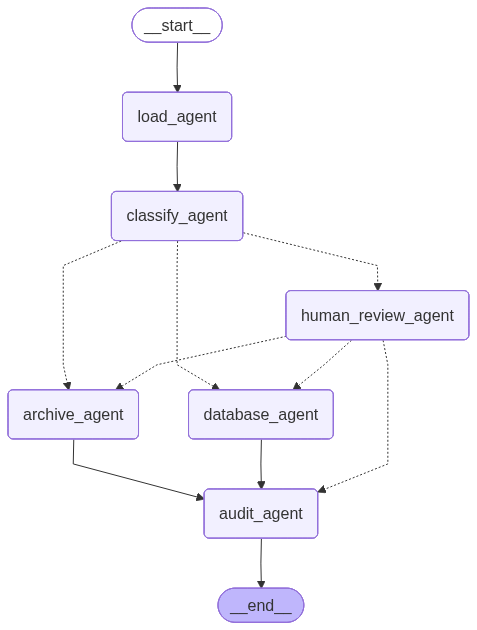

In [132]:
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies; ignore if it fails in basic environment
    pass

In [133]:

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def create_initial_state(document_path: str, document_id: str, document_name: str) -> DocumentProcessingState:
    """Create initial state."""
    return DocumentProcessingState(
        document_path=document_path,
        document_id=document_id,
        document_name=document_name,
        raw_text='',
        extraction_method='',
        num_pages=0,
        classification='',
        classification_confidence=0,
        classification_reasoning='',
        next_agent='',
        database_status=None,
        database_record_id=None,
        archive_status=None,
        human_decision=None,
        human_reviewer=None,
        human_review_timestamp=None,
        human_review_notes=None,
        audit_status='',
        audit_log_path='',
        processing_complete=False,
        final_result={}
    )

def display_results(final_state: DocumentProcessingState):
    """Display processing results."""
    print(f"\n{'='*70}")
    print(f"PROCESSING RESULTS")
    print(f"{'='*70}")

    print(f"\nDocument: {final_state['document_name']}")
    print(f"Document ID: {final_state['document_id']}")
    print(f"Classification: {final_state['classification']}")
    print(f"Confidence: {final_state['classification_confidence']}%")
    print(f"Routing: {final_state['next_agent'].upper()}")

    if final_state['database_status']:
        print(f"Database: {final_state['database_status']}")
    if final_state['archive_status']:
        print(f"Archive: {final_state['archive_status']}")
    if final_state['human_decision']:
        print(f"Human Decision: {final_state['human_decision']}")

    print(f"Audit: {final_state['audit_status']}")
    print(f"Complete: {final_state['processing_complete']}")
    print(f"{'='*70}\n")

print('Helper functions defined')


Helper functions defined


In [134]:
# ============================================================================
# PROCESS ALL PDFs FROM /tmp/data/
# ============================================================================

print("\n" + "="*70)
print("PROCESSING PDFs FROM /tmp/data/ FOLDER")
print("="*70)

hitl_threads =[]

# Rediscover PDFs (in case new ones were added)
available_pdfs = discover_pdfs_from_path()

if not available_pdfs:
    print(f"\nNo PDF files found in {PDF_DATA_PATH}")
    print(f"\nTo test the system:")
    print(f"  1. Upload PDF files to: {PDF_DATA_PATH}")
    print(f"  2. Re-run this cell")
else:
    print(f"\nProcessing {len(available_pdfs)} document(s)...\n")

    processed_results = []

    # Process each PDF
    for idx, (filename, filepath) in enumerate(available_pdfs.items(), 1):
        print(f"\n{'='*70}")
        print(f"[{idx}/{len(available_pdfs)}] {filename}")
        print(f"{'='*70}")

        # Create unique document ID
        doc_id = f"DOC_{idx:03d}_{filename.replace('.pdf', '').replace('.PDF', '')[:40]}"

        # Create unique thread ID
        config = {"configurable": {"thread_id": f"Thread_{idx:03d}"}}

        # Create initial state
        initial_state = create_initial_state(
            document_path=filepath,
            document_id=doc_id,
            document_name=filename
        )

        # Run through workflow
        try:
            final_state = compiled_graph.invoke(initial_state,config)
            processed_results.append(final_state)
            display_results(final_state)
            if compiled_graph.get_state(config).next:
                hitl_threads.append(config["configurable"]["thread_id"])

            # Add small delay between API calls
            import time
            if idx < len(available_pdfs):
                time.sleep(1)

        except Exception as e:
            print(f"\nError processing {filename}: {str(e)}")

    # Final Summary
    print(f"\n{'='*70}")
    print(f"BATCH PROCESSING COMPLETE")
    print(f"{'='*70}")

    successful = sum(1 for r in processed_results if r['processing_complete'])
    print(f"\nTotal Processed: {len(processed_results)}/{len(available_pdfs)}")
    print(f" Successful: {successful}")
    print(f" Results stored in database and audit logs")


PROCESSING PDFs FROM /tmp/data/ FOLDER

Processing 29 document(s)...


[1/29] 01_copyright_infringement_photography.pdf

[LOAD] Processing document: 01_copyright_infringement_photography.pdf
  [1/2] Attempting text extraction with PyPDF2...
  Text extraction successful (3155 chars)
  Loaded via text_extraction (2 pages)

[CLASSIFY] Analyzing document content...
  Classification: Cease (Confidence: 98%)

[ROUTER] Confidence: 98% | Threshold: 90%
  → Route: DATABASE AGENT

[DATABASE] Storing cease request...
  Stored in database (Record ID: 4)

[AUDIT] Creating compliance audit trail...
  Audit trail saved

PROCESSING RESULTS

Document: 01_copyright_infringement_photography.pdf
Document ID: DOC_001_01_copyright_infringement_photography
Classification: Cease
Confidence: 98%
Routing: 
Database: success
Audit: success
Complete: True


[2/29] 02_trademark_infringement_tech.pdf

[LOAD] Processing document: 02_trademark_infringement_tech.pdf
  [1/2] Attempting text extraction with PyPDF2...
 

In [135]:
print(f"HITL THREADS: {hitl_threads}")

HITL THREADS: ['Thread_026', 'Thread_027', 'Thread_028', 'Thread_029']


In [136]:
# ============================================================================
# TEST HUMAN IN THE LOOP
# ============================================================================

# Look for Thread ID which went for HITL and update it below

# Check current state (paused at human_review_agent)

for thread in hitl_threads:
    print("Resuming from human review...")
    config = {"configurable": {"thread_id": thread}}
    try:
      # 1. Get the current paused state from the checkpoint
      current_paused_state_values = compiled_graph.get_state(config).values

      # 2. Define the human decision (from the input provided by the user in the prompt)
      human_decision_value = 'cease'

      # 3. Update the *local* state dictionary with the human decision and other relevant info
      current_paused_state_values['human_decision'] = human_decision_value
      current_paused_state_values['human_reviewer'] = 'External System'
      current_paused_state_values['human_review_timestamp'] = datetime.now().isoformat()
      current_paused_state_values['human_review_notes'] = f'Manual review: {human_decision_value}'

      # 4. Explicitly update the checkpoint with the modified state.
      compiled_graph.update_state(config, current_paused_state_values)

      # 5. Stream the graph to continue execution.
      for s in compiled_graph.stream(None,config):
          pass

      # 6. After the stream has completed, get the *final* complete state from the checkpoint.
      final_state_resumed = compiled_graph.get_state(config).values

      print("\nHuman review completed. Workflow resumed and finished.")
      display_results(final_state_resumed)

    except Exception as e:
      print(f"Error resuming workflow: {str(e)}")

Resuming from human review...

[ROUTER] Confidence: 82% | Threshold: 90%
  → Route: HUMAN REVIEW

[HUMAN REVIEW] Document requires manual review
  Classification: Cease (Confidence: 82%)
  Reason: The document explicitly requests a temporary suspension of outbound communications to the client and asks the recipient to provide legal justification for any further contact, which aligns with a cease & desist style request.

--- Document Preview ---
Lowell & Partners — Regulatory Practice

33 Ironforge Lane, Regulatory Square

Customer Services Division

Date: October 10, 2025

Our firm represents
--- End Preview ---

  Human decision received: cease

[DATABASE] Storing cease request...
  Stored in database (Record ID: 24)

[AUDIT] Creating compliance audit trail...
  Audit trail saved

Human review completed. Workflow resumed and finished.

PROCESSING RESULTS

Document: notice_2.pdf
Document ID: DOC_026_notice_2
Classification: Cease
Confidence: 82%
Routing: 
Database: success
Human Decisi

In [137]:
# ============================================================================
# RESULTS DISPLAY
# ============================================================================

print("\n" + "="*70)
print("DATABASE RESULTS: Stored Cease Requests")
print("="*70)

try:
    conn = sqlite3.connect(str(DB_PATH))
    cursor = conn.cursor()
    cursor.execute('SELECT id, document_id, document_name, date_received FROM cease_requests')
    records = cursor.fetchall()

    if records:
        print(f"\nTotal: {len(records)} Cease Requests\n")
        for rec in records:
            print(f"  ID: {rec[0]}, Document: {rec[2]}, Date: {rec[3]}")
    else:
        print("\nNo cease requests stored yet.")
    conn.close()
except Exception as e:
    print(f"Error: {str(e)}")

print("\n" + "="*70)
print("ARCHIVE LOG: Irrelevant Documents")
print("="*70)

if ARCHIVE_LOG_PATH.exists():
    print(f"\nArchived Entries:\n")
    with open(ARCHIVE_LOG_PATH, 'r') as f:
        content = f.read()
        print(content if content else "  (Empty)")
else:
    print("\nArchive log not created yet.")

print("\n" + "="*70)
print("AUDIT TRAIL: Complete Processing Log")
print("="*70)

if AUDIT_LOG_PATH.exists():
    with open(AUDIT_LOG_PATH, 'r') as f:
        audit_data = json.load(f)
        print(json.dumps(audit_data, indent=2))
else:
    print("Audit log not created yet.")



DATABASE RESULTS: Stored Cease Requests

Total: 27 Cease Requests

  ID: 1, Document: 02_trademark_infringement_tech.pdf, Date: 2026-03-22T08:10:49.706708
  ID: 2, Document: 04_defamation_online_review.pdf, Date: 2026-03-22T08:10:53.003819
  ID: 3, Document: notice_4.pdf, Date: 2026-03-22T08:11:02.369688
  ID: 4, Document: 01_copyright_infringement_photography.pdf, Date: 2026-03-22T08:15:21.993797
  ID: 5, Document: 02_trademark_infringement_tech.pdf, Date: 2026-03-22T08:15:24.896117
  ID: 6, Document: 03_trade_secret_misappropriation.pdf, Date: 2026-03-22T08:15:28.284804
  ID: 7, Document: 04_defamation_online_review.pdf, Date: 2026-03-22T08:15:31.545006
  ID: 8, Document: 05_patent_infringement_medical_device.pdf, Date: 2026-03-22T08:15:37.054191
  ID: 9, Document: 06_harassment_workplace.pdf, Date: 2026-03-22T08:15:51.509669
  ID: 10, Document: 07_software_license_violation.pdf, Date: 2026-03-22T08:16:05.851538
  ID: 11, Document: 08_non_compete_violation.pdf, Date: 2026-03-22T08:1